In [1]:
from copy import deepcopy
import random
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


In [2]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)



Device: cuda


In [3]:
import sys

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("PyTorch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: /venv/main/bin/python
PyTorch: 2.11.0+cu128
PyTorch CUDA build: 12.8
CUDA available: True
GPU: NVIDIA GeForce RTX 5090


In [4]:
# Keep the paths and CSV loading procedure aligned with data_loading.ipynb.
DATA_ROOT = Path("/workspace/05_Data")
MANIFEST_DIR = DATA_ROOT / "manifests"

TRAIN_CSV = MANIFEST_DIR / "train_classifier.csv"
VAL_CSV = MANIFEST_DIR / "val_classifier.csv"
TEST_CSV = MANIFEST_DIR / "test_classifier.csv"

dtype_map = {
    "source_id": str,
    "generator_source_id": str,
}

train_df = pd.read_csv(TRAIN_CSV, dtype=dtype_map)
val_df = pd.read_csv(VAL_CSV, dtype=dtype_map)
test_df = pd.read_csv(TEST_CSV, dtype=dtype_map)


In [5]:
class LSBClassificationDataset(Dataset):
    def __init__(self, dataframe, data_root, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.data_root = Path(data_root)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image_path = self.data_root / row["image_path"]

        with Image.open(image_path) as image_file:
            image = image_file.convert("RGB")

        label = int(row["label"])
        if self.transform is not None:
            image = self.transform(image)

        return image, label


In [6]:
# Apply one orientation-only augmentation to each training image.
orientation_augmentations = transforms.RandomChoice([
    transforms.RandomRotation(degrees=(90, 90)),
    transforms.RandomRotation(degrees=(180, 180)),
    transforms.RandomRotation(degrees=(270, 270)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomVerticalFlip(p=1.0),
])

train_transform = transforms.Compose([
    orientation_augmentations,
    transforms.ToTensor(),
])
evaluation_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = LSBClassificationDataset(
    dataframe=train_df,
    data_root=DATA_ROOT,
    transform=train_transform,
)
val_dataset = LSBClassificationDataset(
    dataframe=val_df,
    data_root=DATA_ROOT,
    transform=evaluation_transform,
)
test_dataset = LSBClassificationDataset(
    dataframe=test_df,
    data_root=DATA_ROOT,
    transform=evaluation_transform,
)


In [7]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)


In [8]:
class SRMResidualLayer(nn.Module):
    """Fixed high-pass/SRM-style residual extraction for RGB input.

    Three normalized high-pass filters are applied independently to each
    colour channel. Input shape: [B, 3, H, W]
    Output shape: [B, 9, H, W]
    """

    def __init__(self):
        super().__init__()

        # 3x3 second-order directional residual, padded to 5x5.
        directional = torch.tensor([
            [0, 0,  0, 0, 0],
            [0, 0,  0, 0, 0],
            [0, 1, -2, 1, 0],
            [0, 0,  0, 0, 0],
            [0, 0,  0, 0, 0],
        ], dtype=torch.float32) / 2.0

        # 3x3 square residual, padded to 5x5.
        square_3x3 = torch.tensor([
            [0,  0,  0,  0, 0],
            [0, -1,  2, -1, 0],
            [0,  2, -4,  2, 0],
            [0, -1,  2, -1, 0],
            [0,  0,  0,  0, 0],
        ], dtype=torch.float32) / 4.0

        # 5x5 square residual.
        square_5x5 = torch.tensor([
            [-1,  2,  -2,  2, -1],
            [ 2, -6,   8, -6,  2],
            [-2,  8, -12,  8, -2],
            [ 2, -6,   8, -6,  2],
            [-1,  2,  -2,  2, -1],
        ], dtype=torch.float32) / 12.0

        filters = torch.stack([
            directional,
            square_3x3,
            square_5x5,
        ]).unsqueeze(1)  # [3 filters, 1, 5, 5]

        # groups=3 means each RGB channel is filtered independently.
        # Each channel receives all three filters: 3 channels × 3 filters = 9 maps.
        filters = filters.repeat(3, 1, 1, 1)
        self.register_buffer("filters", filters)

    def forward(self, x):
        return F.conv2d(
            x,
            self.filters,
            bias=None,
            stride=1,
            padding=2,
            groups=3,
        )


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)

        return out


In [9]:
class DualStreamSteganalysisCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Stream 1: full RGB image information.
        self.rgb_branch = nn.Sequential(
            ResidualBlock(3, 16, stride=1),
            ResidualBlock(16, 32, stride=1),
        )

        # Stream 2: fixed high-pass residuals followed by learnable processing.
        self.srm = SRMResidualLayer()
        self.residual_branch = nn.Sequential(
            ResidualBlock(9, 16, stride=1),
            ResidualBlock(16, 32, stride=1),
        )

        # The two 32-channel streams are concatenated -> 64 channels.
        # Downsampling happens only after both streams have extracted features.
        self.fusion = nn.Sequential(
            ResidualBlock(64, 64, stride=2),   # 128x128 -> 64x64
            ResidualBlock(64, 128, stride=2),  # 64x64 -> 32x32
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 2),
        )

    def forward(self, images):
        rgb_features = self.rgb_branch(images)

        residual_maps = self.srm(images)
        residual_features = self.residual_branch(residual_maps)

        fused = torch.cat(
            [rgb_features, residual_features],
            dim=1,
        )

        fused = self.fusion(fused)
        fused = self.global_pool(fused)
        fused = torch.flatten(fused, 1)

        return self.classifier(fused)


In [10]:
model = DualStreamSteganalysisCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

NUM_EPOCHS = 3
history = {
    "train_accuracy": [],
    "val_accuracy": [],
}

# Architecture smoke check for 128x128 RGB input.
with torch.no_grad():
    dummy_input = torch.zeros(2, 3, 128, 128, device=device)
    dummy_output = model(dummy_input)

print("Model output shape:", dummy_output.shape)
print(
    "Trainable parameters:",
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}",
)


Model output shape: torch.Size([2, 2])
Trainable parameters: 352,514


In [11]:
from torchinfo import summary

summary(
    model,
    input_size=(1, 3, 128, 128),
    col_names=("input_size", "output_size", "num_params", "trainable"),
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
DualStreamSteganalysisCNN                [1, 3, 128, 128]          [1, 2]                    --                        True
├─Sequential: 1-1                        [1, 3, 128, 128]          [1, 32, 128, 128]         --                        True
│    └─ResidualBlock: 2-1                [1, 3, 128, 128]          [1, 16, 128, 128]         --                        True
│    │    └─Sequential: 3-1              [1, 3, 128, 128]          [1, 16, 128, 128]         80                        True
│    │    └─Conv2d: 3-2                  [1, 3, 128, 128]          [1, 16, 128, 128]         432                       True
│    │    └─BatchNorm2d: 3-3             [1, 16, 128, 128]         [1, 16, 128, 128]         32                        True
│    │    └─ReLU: 3-4                    [1, 16, 128, 128]         [1, 16, 128, 128]         --                        --
│    

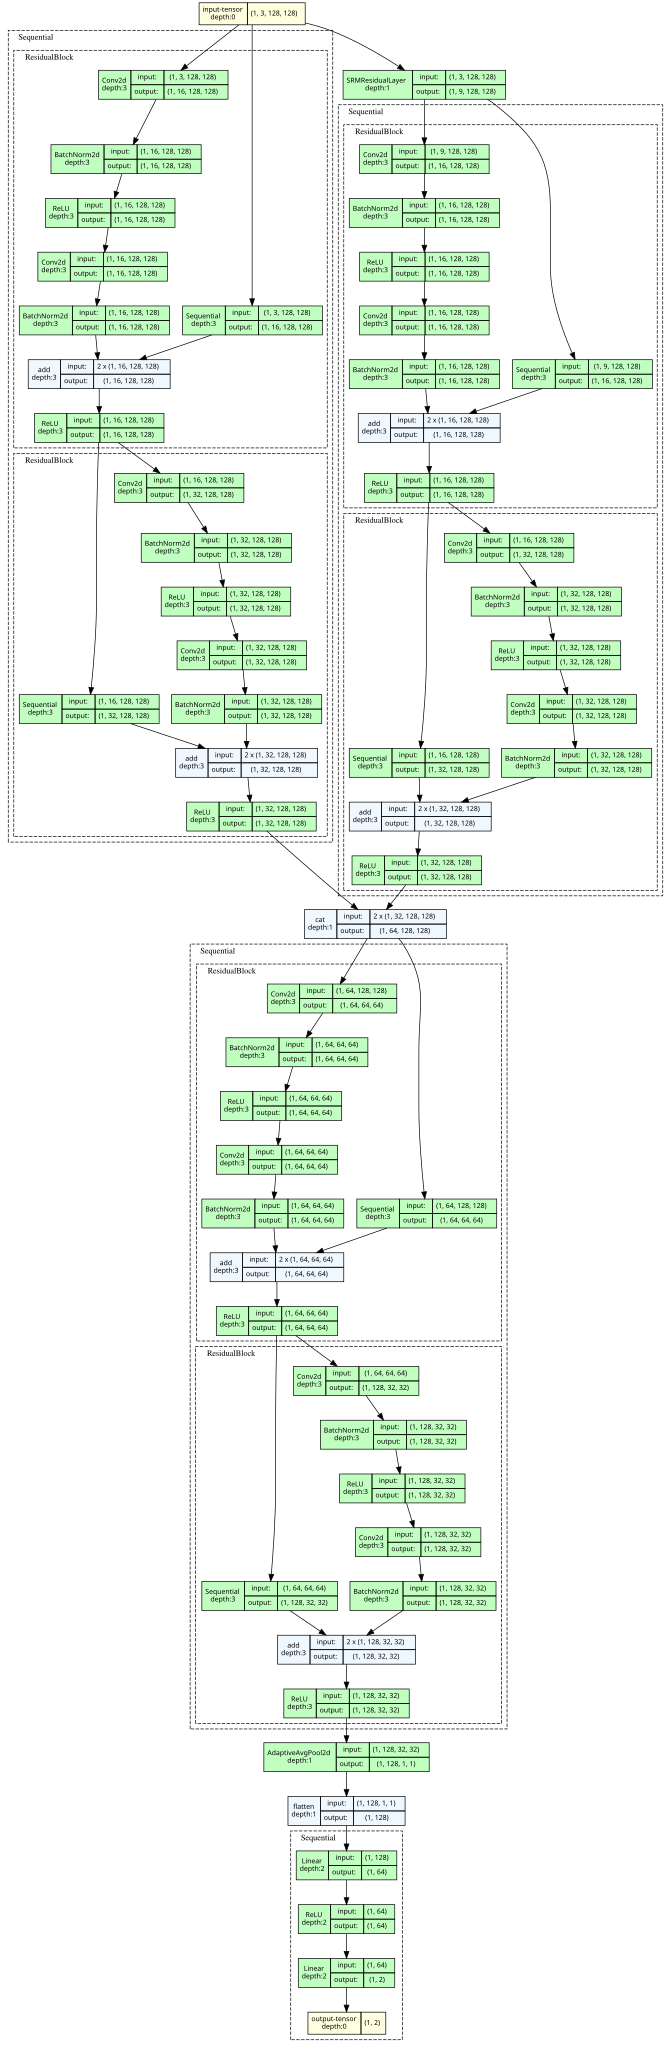

In [12]:
from torchview import draw_graph

model_graph = draw_graph(
    model,
    input_size=(1, 3, 128, 128),
    expand_nested=True,
)

model_graph.visual_graph

In [13]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        #loss is cross entropy loss
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (outputs.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            predictions = outputs.argmax(dim=1)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (predictions == labels).sum().item()
            total_samples += batch_size
            all_labels.append(labels.cpu())
            all_predictions.append(predictions.cpu())

    return (
        total_loss / total_samples,
        total_correct / total_samples,
        torch.cat(all_labels),
        torch.cat(all_predictions),
    )


In [14]:
best_val_accuracy = -1.0
best_model_weights = deepcopy(model.state_dict())

for epoch in range(NUM_EPOCHS):
    train_loss, train_accuracy = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    val_loss, val_accuracy, _, _ = evaluate(
        model, val_loader, criterion, device
    )

    history["train_accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_model_weights = deepcopy(model.state_dict())

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"train loss: {train_loss:.4f} | train accuracy: {train_accuracy:.4f} | "
        f"val loss: {val_loss:.4f} | val accuracy: {val_accuracy:.4f}"
    )

model.load_state_dict(best_model_weights)
print(f"Best validation accuracy: {best_val_accuracy:.4f}")


Epoch 1/3 | train loss: 0.2005 | train accuracy: 0.9025 | val loss: 0.1218 | val accuracy: 0.9508
Epoch 2/3 | train loss: 0.1006 | train accuracy: 0.9601 | val loss: 0.3492 | val accuracy: 0.8868
Epoch 3/3 | train loss: 0.0890 | train accuracy: 0.9655 | val loss: 1.1055 | val accuracy: 0.7709
Best validation accuracy: 0.9508


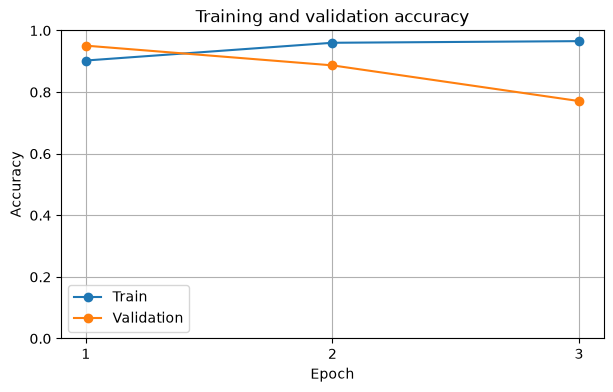

In [15]:
epochs = range(1, NUM_EPOCHS + 1)
plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_accuracy"], marker="o", label="Train")
plt.plot(epochs, history["val_accuracy"], marker="o", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.xticks(list(epochs))
plt.ylim(0.0, 1.0)
plt.grid(True)
plt.legend()
plt.show()
